<a href="https://colab.research.google.com/github/sanodyaJinadasa/Data-Mining/blob/main/Last_Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# STREAMFLIX DATA PIPELINE OPTIMIZATION


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

### DATA PREPROCESSING & CHURN PREDICTION (SVM)

In [25]:
print("="*60)
print("TOPIC 1: CHURN PREDICTION")
print("="*60)

# Create dataset
df = pd.DataFrame({
    'User_ID':[1,2,3,4,5,6,7,8],
    'Age':[20,25,45,np.nan,50,52,23,40],
    'Daily_Minutes':[120,140,10,150,5,12,np.nan,15],
    'Sub_Canceled':[0,0,1,0,1,1,0,1]
})

print("\nOriginal Dataset")
print(df)


TOPIC 1: CHURN PREDICTION

Original Dataset
   User_ID   Age  Daily_Minutes  Sub_Canceled
0        1  20.0          120.0             0
1        2  25.0          140.0             0
2        3  45.0           10.0             1
3        4   NaN          150.0             0
4        5  50.0            5.0             1
5        6  52.0           12.0             1
6        7  23.0            NaN             0
7        8  40.0           15.0             1


## Task 1.1
###  Missing Value Imputation

In [26]:
print("\nMedian Imputation")

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Daily_Minutes'].fillna(df['Daily_Minutes'].median(), inplace=True)

print(df)


Median Imputation
   User_ID   Age  Daily_Minutes  Sub_Canceled
0        1  20.0          120.0             0
1        2  25.0          140.0             0
2        3  45.0           10.0             1
3        4  40.0          150.0             0
4        5  50.0            5.0             1
5        6  52.0           12.0             1
6        7  23.0           15.0             0
7        8  40.0           15.0             1


/tmp/ipykernel_1646/4038170707.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1646/4038170707.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

## Task 1.2
### Scaling


In [27]:
X = df[['Age','Daily_Minutes']]
y = df['Sub_Canceled']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled Features")
print(X_scaled)



Scaled Features
[[-1.43592647  1.00703931]
 [-1.01046678  1.33386748]
 [ 0.691372   -0.79051564]
 [ 0.26591231  1.49728157]
 [ 1.1168317  -0.87222269]
 [ 1.28701558 -0.75783283]
 [-1.18065065 -0.7088086 ]
 [ 0.26591231 -0.7088086 ]]




# Task 1.3
# Linear SVM


In [28]:
svm = SVC(kernel='linear')
svm.fit(X_scaled,y)

w = svm.coef_[0]
b = svm.intercept_[0]

print("\nLinear SVM Parameters")
print("w1 =", w[0])
print("w2 =", w[1])
print("bias =", b)

print("\nDecision Boundary Equation")
print(f"{w[0]:.4f}x1 + {w[1]:.4f}x2 + ({b:.4f}) = 0")


Linear SVM Parameters
w1 = 1.0388241777176146
w2 = -0.6810140849855161
bias = -0.2564509041178326

Decision Boundary Equation
1.0388x1 + -0.6810x2 + (-0.2565) = 0


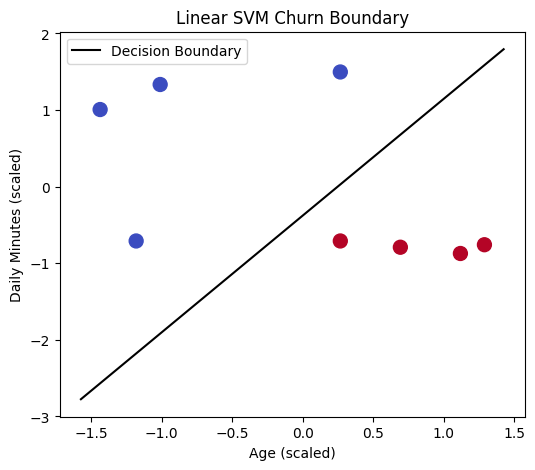

In [29]:
plt.figure(figsize=(6,5))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=y,
    cmap='coolwarm',
    s=100
)

ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0],xlim[1],100)
yy = -(w[0]*xx + b)/w[1]

plt.plot(xx,yy,'k-',label='Decision Boundary')

plt.xlabel("Age (scaled)")
plt.ylabel("Daily Minutes (scaled)")
plt.title("Linear SVM Churn Boundary")
plt.legend()
plt.show()


In [30]:
score = 0.0

if score >= 0:
    prediction = "Positive Class"
else:
    prediction = "Negative Class"

print("\nTie-break Example")
print("Decision Score =", score)
print("Predicted Class =", prediction)


Tie-break Example
Decision Score = 0.0
Predicted Class = Positive Class


## TOPIC 2

In [31]:
print("\n")
print("="*60)
print("TOPIC 2: LDA TOPIC MODELING")
print("="*60)

complaints_corpus = [
"The video stream keeps buffering and the video quality is lagging",
"I hate the new app update the screen freezes on my phone constantly",
"Why did you raise the subscription price it is way too expensive now",
"The monthly cost is overpriced for this streaming platform",
"Horrible app playback crashes every single time I press play",
"Customer service refused to refund my overpriced renewal fee"
]



TOPIC 2: LDA TOPIC MODELING


In [32]:
vectorizer = CountVectorizer(stop_words='english')

X_text = vectorizer.fit_transform(complaints_corpus)

print("\nVocabulary")
print(vectorizer.get_feature_names_out())

print("\nDocument-Term Matrix Shape")
print(X_text.shape)



Vocabulary
['app' 'buffering' 'constantly' 'cost' 'crashes' 'customer' 'did'
 'expensive' 'fee' 'freezes' 'hate' 'horrible' 'keeps' 'lagging' 'monthly'
 'new' 'overpriced' 'phone' 'platform' 'play' 'playback' 'press' 'price'
 'quality' 'raise' 'refund' 'refused' 'renewal' 'screen' 'service'
 'single' 'stream' 'streaming' 'subscription' 'time' 'update' 'video'
 'way']

Document-Term Matrix Shape
(6, 38)


In [33]:
lda = LatentDirichletAllocation(
    n_components=2,
    random_state=42
)

lda.fit(X_text)

words = vectorizer.get_feature_names_out()

print("\nTOPICS")

for topic_idx, topic in enumerate(lda.components_):

    top_words_idx = topic.argsort()[-4:][::-1]

    top_words = [words[i] for i in top_words_idx]

    print(f"\nTheme {topic_idx+1}")
    print(top_words)



TOPICS

Theme 1
['overpriced', 'app', 'single', 'playback']

Theme 2
['video', 'app', 'phone', 'new']


In [34]:
topic_matrix = lda.transform(X_text)

print("\nDocument Topic Probabilities")
print(np.round(topic_matrix,3))



Document Topic Probabilities
[[0.065 0.935]
 [0.06  0.94 ]
 [0.925 0.075]
 [0.092 0.908]
 [0.94  0.06 ]
 [0.932 0.068]]


## Topic 3

In [35]:
print("\n")
print("="*60)
print("TOPIC 3: ASSOCIATION RULES")
print("="*60)

transactions = [
['Shirt','Poster','Mug'],
['Shirt','Poster'],
['Shirt','Keychain'],
['Poster','Mug'],
['Shirt','Poster','Mug','Keychain']
]



TOPIC 3: ASSOCIATION RULES


In [36]:
te = TransactionEncoder()

encoded = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    encoded,
    columns=te.columns_
)

print("\nOne-Hot Encoded Transactions")
print(basket)



One-Hot Encoded Transactions
   Keychain    Mug  Poster  Shirt
0     False   True    True   True
1     False  False    True   True
2      True  False   False   True
3     False   True    True  False
4      True   True    True   True


In [37]:
frequent_itemsets = apriori(
    basket,
    min_support=0.40,
    use_colnames=True
)

print("\nFrequent Itemsets")
print(frequent_itemsets)


Frequent Itemsets
   support              itemsets
0      0.4            (Keychain)
1      0.6                 (Mug)
2      0.8              (Poster)
3      0.8               (Shirt)
4      0.4     (Shirt, Keychain)
5      0.6         (Poster, Mug)
6      0.4          (Shirt, Mug)
7      0.6       (Shirt, Poster)
8      0.4  (Shirt, Poster, Mug)


In [38]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.70
)

print("\nAssociation Rules")
print(rules[['antecedents',
             'consequents',
             'support',
             'confidence',
             'lift']])

# Check Lift=1 rules

lift_one = rules[np.isclose(rules['lift'],1)]

print("\nRules With Lift = 1")
print(lift_one)


Association Rules
    antecedents consequents  support  confidence    lift
0    (Keychain)     (Shirt)      0.4        1.00  1.2500
1      (Poster)       (Mug)      0.6        0.75  1.2500
2         (Mug)    (Poster)      0.6        1.00  1.2500
3       (Shirt)    (Poster)      0.6        0.75  0.9375
4      (Poster)     (Shirt)      0.6        0.75  0.9375
5  (Shirt, Mug)    (Poster)      0.4        1.00  1.2500

Rules With Lift = 1
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


## TOPIC 4

In [39]:

print("\n")
print("="*60)
print("TOPIC 4: VIEWER BEHAVIOR PROFILING")
print("="*60)

users = pd.DataFrame({
    'User':['U1','U2','U3','U4','U5','U6','U7','U8'],
    'SciFi_Ratio':[0.85,0.80,0.20,0.15,0.70,0.30,0.90,0.25],
    'Session_Duration':[0.90,0.75,0.30,0.20,0.85,0.40,0.20,0.80],
    'Genre_Label':[0,0,1,1,0,1,0,1]
})

X = users[['SciFi_Ratio','Session_Duration']]
y = users['Genre_Label']




TOPIC 4: VIEWER BEHAVIOR PROFILING



Support Vectors
[[0.85 0.9 ]
 [0.8  0.75]
 [0.7  0.85]
 [0.9  0.2 ]
 [0.2  0.3 ]
 [0.15 0.2 ]
 [0.3  0.4 ]
 [0.25 0.8 ]]


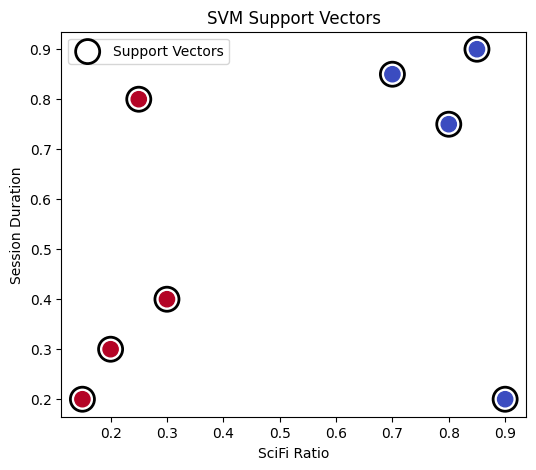

In [40]:
svm_linear = SVC(kernel='linear')

svm_linear.fit(X,y)

support_vectors = svm_linear.support_vectors_

print("\nSupport Vectors")
print(support_vectors)

# Plot Support Vectors

plt.figure(figsize=(6,5))

plt.scatter(
    X['SciFi_Ratio'],
    X['Session_Duration'],
    c=y,
    cmap='coolwarm',
    s=120
)

plt.scatter(
    support_vectors[:,0],
    support_vectors[:,1],
    s=300,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)

plt.xlabel("SciFi Ratio")
plt.ylabel("Session Duration")
plt.title("SVM Support Vectors")
plt.legend()
plt.show()

In [41]:
linear_model = SVC(kernel='linear')
rbf_model = SVC(kernel='rbf')

linear_model.fit(X,y)
rbf_model.fit(X,y)

linear_acc = linear_model.score(X,y)
rbf_acc = rbf_model.score(X,y)

print("\nKernel Comparison")
print("Linear Accuracy:",linear_acc)
print("RBF Accuracy:",rbf_acc)


Kernel Comparison
Linear Accuracy: 1.0
RBF Accuracy: 1.0


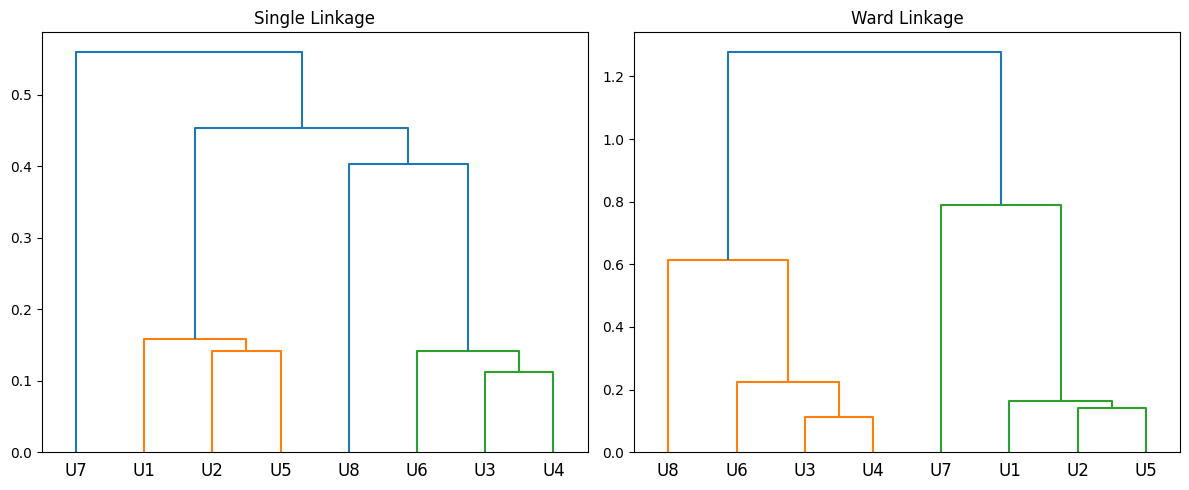

In [42]:
single_link = linkage(X, method='single')
ward_link = linkage(X, method='ward')

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

dendrogram(
    single_link,
    labels=users['User'].values
)

plt.title("Single Linkage")

plt.subplot(1,2,2)

dendrogram(
    ward_link,
    labels=users['User'].values
)

plt.title("Ward Linkage")

plt.tight_layout()
plt.show()



User Assignments
  User  Genre_Label  Cluster_ID
0   U1            0           0
1   U2            0           0
2   U3            1           1
3   U4            1           1
4   U5            0           0
5   U6            1           1
6   U7            0           0
7   U8            1           1

Genre vs Cluster Comparison
Cluster_ID   0  1
Genre_Label      
0            4  0
1            0  4


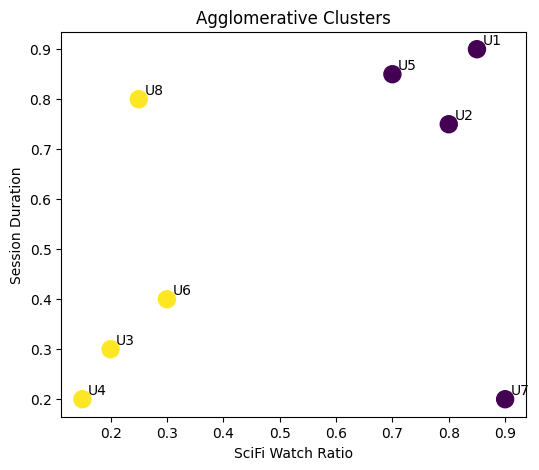


Pipeline Complete.


In [43]:
agg = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

cluster_labels = agg.fit_predict(X)

users['Cluster_ID'] = cluster_labels

print("\nUser Assignments")
print(users[['User',
             'Genre_Label',
             'Cluster_ID']])

# Compare supervised vs unsupervised

comparison = pd.crosstab(
    users['Genre_Label'],
    users['Cluster_ID']
)

print("\nGenre vs Cluster Comparison")
print(comparison)

# Visualize clusters

plt.figure(figsize=(6,5))

plt.scatter(
    users['SciFi_Ratio'],
    users['Session_Duration'],
    c=cluster_labels,
    cmap='viridis',
    s=150
)

for i,row in users.iterrows():
    plt.text(
        row['SciFi_Ratio']+0.01,
        row['Session_Duration']+0.01,
        row['User']
    )

plt.xlabel("SciFi Watch Ratio")
plt.ylabel("Session Duration")
plt.title("Agglomerative Clusters")
plt.show()

print("\nPipeline Complete.")